### Simulating 1D brownian motion for a single particle using the Langevin equation 

$m\ddot{x}(t) = -\gamma\dot{x} + \eta(t)$

where $\eta(t)$ is the stochastic gaussian noise term 

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # or 'sans-serif' for a modern look
    "font.serif": ["Computer Modern Roman"],  # default LaTeX font
    "axes.labelsize": 16,    # LaTeX font size
    "font.size": 15,
    "legend.fontsize": 15,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

In [52]:
#constants and variables

times = np.linspace(0,10,1001)
m = 0.3
b = 0.05
a = 1

h = 0.01
t0 = 0
Y0 = [0,0]

In [53]:
def F(Y, t, Z):
    return np.array([Y[1], (-b/m)*Y[1] + (a/m)*Z])

Integrator class (possibility to add other methods) using second order Runge-Kutta

In [54]:
class Integrator:

    def RK2(F, Y0, t0, h):
        Y_list = []
        for j in range(len(times)):

            Z = np.random.normal(loc=0)
            k1 = h*F(Y0, t0, Z)
            k2 = h*F(Y0 + k1, t0 + h*j, Z)

            Y = Y0 + 0.5*(k1 + k2)
            Y0 = Y
            t0 = t0 + h*j

            Y_list.append(Y)

        return np.array(Y_list)

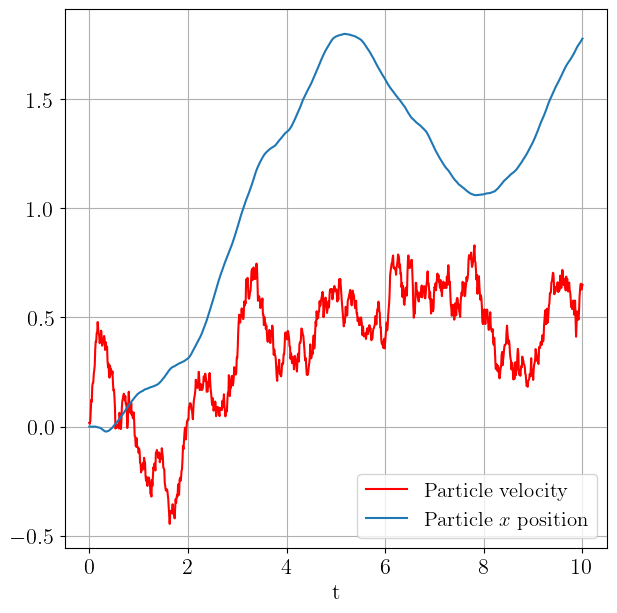

In [55]:
plt.figure(figsize=(7,7))
plt.plot(times, Integrator.RK2(F,Y0,t0,h)[:,1], color="red", label=r"Particle velocity")
plt.plot(times, Integrator.RK2(F,Y0,t0,h)[:,0], label = r"Particle $x$ position")
plt.grid(True)
plt.xlabel("t")
plt.legend()
plt.show()